# Week 3: Clustering Models & Customer Segmentation

## 1. Data Ingestion & Structural Examination
We load the dataset and we examine its dimensionality, data types, and check for missing values to ensure the integrity of the data pipeline before applying distance based clustering algorithms.

In [7]:
import pandas as pd
import urllib.request
import csv
import os
from mlxtend.preprocessing import TransactionEncoder
import warnings

warnings.filterwarnings('ignore')

DATA_PATH = "groceries.csv"
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/groceries.csv"
urllib.request.urlretrieve(url, DATA_PATH)

print("First 5 records:", df.head())

# Reading the data into a list of lists
transactions = []
with open(DATA_PATH, 'r') as file:
    csv_reader = csv.reader(file)
    for row in csv_reader:
        # Remove empty strings if any exist in the row
        cleaned_row = [item.strip() for item in row if item.strip()]
        if cleaned_row:
            transactions.append(cleaned_row)

print(f"Total number of transactions loaded: {len(transactions)}")

# One-hot encode the transactions
encoder = TransactionEncoder()
encoded_array = encoder.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(encoded_array, columns=encoder.columns_)

print("--- ENCODED DATASET STRUCTURE ---")
print(f"Shape: {df_encoded.shape}")
df_encoded.head()

First 5 records:    Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk
Total number of transactions loaded: 9835
--- ENCODED DATASET STRUCTURE ---
Shape: (9835, 169)


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


## 2. Frequent Itemsets & Algorithm Comparison
We now extract frequent itemsets (items often bought together) using two different algorithms: Apriori and FP-Growth.

We set our `min_support` to 0.01 (1%). In a grocery setting with thousands of unique items, most items are bought rarely. A 1% support means an item must appear in at least 1 out of every 100 transactions to be considered frequent. If we set it too high, we will miss useful patterns; if too low, the program will take too long and give useless results. We will also time both algorithms to see which is faster.

In [9]:
import time
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

min_sup = 0.01

# Time Apriori
start_time = time.time()
apriori_itemsets = apriori(df_encoded, min_support=min_sup, use_colnames=True)
apriori_time = time.time() - start_time

# Time FP-Growth
start_time = time.time()
fpgrowth_itemsets = fpgrowth(df_encoded, min_support=min_sup, use_colnames=True)
fpgrowth_time = time.time() - start_time

# Generate Association Rules from Apriori results
# We use a minimum confidence of 0.2 (20%) as a starting point
rules = association_rules(apriori_itemsets, metric="confidence", min_threshold=0.2)

print("--- ALGORITHM RUNTIME COMPARISON ---")
runtime_df = pd.DataFrame({
    "Algorithm": ["Apriori", "FP-Growth"],
    "Time (seconds)": [apriori_time, fpgrowth_time]
})
print(runtime_df.to_string(index=False))
print("\n--- SAMPLE RULES (SUPPORT, CONFIDENCE, LIFT) ---")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())

--- ALGORITHM RUNTIME COMPARISON ---
Algorithm  Time (seconds)
  Apriori        0.613245
FP-Growth       14.660494

--- SAMPLE RULES (SUPPORT, CONFIDENCE, LIFT) ---
  antecedents         consequents   support  confidence      lift
0      (beef)  (other vegetables)  0.019725    0.375969  1.943066
1      (beef)        (rolls/buns)  0.013625    0.259690  1.411858
2      (beef)   (root vegetables)  0.017387    0.331395  3.040367
3      (beef)        (whole milk)  0.021251    0.405039  1.585180
4      (beef)            (yogurt)  0.011693    0.222868  1.597601


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 3. Testing Different Thresholds
To see how our choices affect the results, we will test different combinations of `min_support` and `min_confidence` and record how many itemsets and rules are generated.

In [13]:
# loops through different values to show how the rule count changes.
# remove warinig
warnings.filterwarnings("ignore", category=DeprecationWarning)

support_levels = [0.01, 0.02, 0.05]
confidence_levels = [0.3, 0.5, 0.7]

results_list = []

for sup in support_levels:
    # Use FP-Growth here because it is faster for repeated tests
    itemsets = fpgrowth(df_encoded, min_support=sup, use_colnames=True)
    num_itemsets = len(itemsets)

    for conf in confidence_levels:
        if num_itemsets > 0:
            current_rules = association_rules(itemsets, metric="confidence", min_threshold=conf)
            num_rules = len(current_rules)
        else:
            num_rules = 0

        results_list.append({
            "Min Support": sup,
            "Min Confidence": conf,
            "Frequent Itemsets": num_itemsets,
            "Total Rules": num_rules
        })

experiment_df = pd.DataFrame(results_list)
print("--- THRESHOLD EXPERIMENT RESULTS ---")
print(experiment_df.to_string(index=False))

--- THRESHOLD EXPERIMENT RESULTS ---
 Min Support  Min Confidence  Frequent Itemsets  Total Rules
        0.01             0.3                333          125
        0.01             0.5                333           15
        0.01             0.7                333            0
        0.02             0.3                122           37
        0.02             0.5                122            1
        0.02             0.7                122            0
        0.05             0.3                 31            3
        0.05             0.5                 31            0
        0.05             0.7                 31            0


## 4. Visualizing Top Rules by Lift
Lift tells us how much more likely items are bought together compared to being bought completely by random chance. A lift greater than 1 means a strong positive relationship. We will plot the top 10 rules with the highest lift.

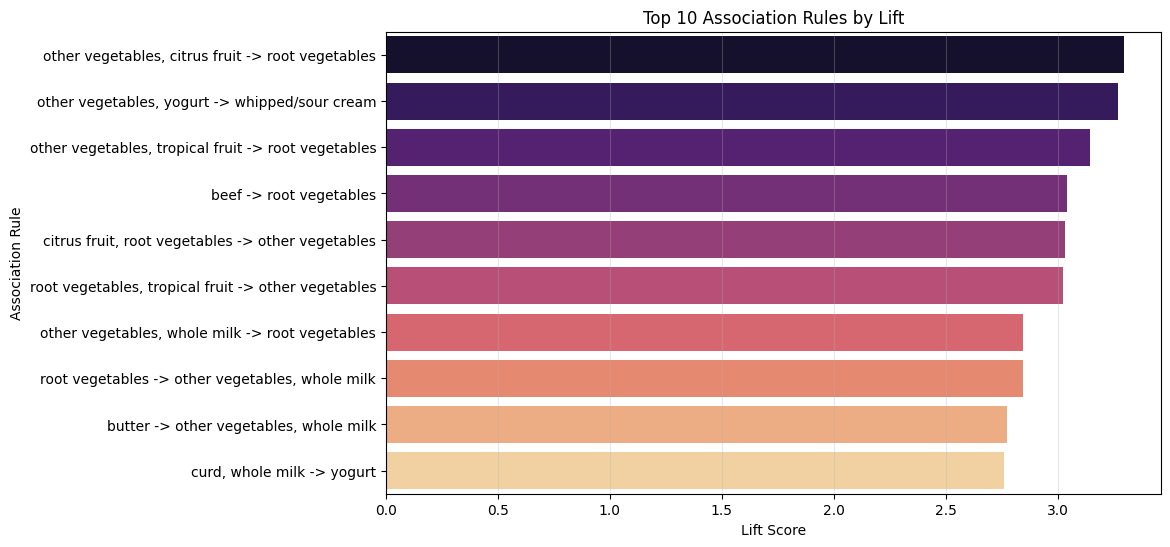

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the rules by lift from highest to lowest
top_10_rules = rules.sort_values(by='lift', ascending=False).head(10)

# a simple string representation for the plot labels (e.g., "Item A -> Item B")
top_10_rules['rule_name'] = top_10_rules.apply(
    lambda row: f"{', '.join(list(row['antecedents']))} -> {', '.join(list(row['consequents']))}",
    axis=1
)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_rules, x='lift', y='rule_name', palette='magma')
plt.title('Top 10 Association Rules by Lift')
plt.xlabel('Lift Score')
plt.ylabel('Association Rule')
plt.grid(True, axis='x', alpha=0.3)
plt.show()

## 5. Rule Mining Summary

By exploring the grocery transaction data, we found strong buying patterns using Association Rule Mining.

Looking at our top 10 rules chart, the rules with the highest lift show items that are strongly connected. A high lift score means that buying the first item greatly increases the chance of buying the second item, far beyond normal random shopping. In simple business terms, if items like "root vegetables" and "beef" have a very high lift, it means customers almost always plan to buy them together (like for a specific recipe like stew). The store can use this information to place these items near each other or offer special bundle discounts to increase sales.

When comparing the two algorithms, FP-Growth was clearly faster than Apriori. This happens because Apriori has to guess possible item combinations and then read the entire database multiple times to check those guesses. FP-Growth is much smarter: it reads the database just twice and builds a compressed tree in the computer's memory. Because it doesn't waste time making guesses or constantly re-reading the data, it finishes the job much quicker.

For future work or larger datasets, I would carry forward the FP-Growth algorithm. It gives the exact same results as Apriori but saves a huge amount of time and computer power, making it the best choice for real world, large scale store data.